<h2>eda.py</h2>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cmu/idl/final_project/idl_project
!ls

Mounted at /content/drive
/content/drive/MyDrive/cmu/idl/final_project/idl_project
 6.+Turbofan+Engine+Degradation+Simulation+Data+Set
 6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip
'Deep learning-based tool wear prediction and its application for machining.pdf'
 eda.py
 evaluate.py
 evaluation_results.png
 implementation_plan.md
 instructions.txt
 lstm2.ipynb
 lstm.ipynb
 lstm_model.pth
 model.py
 Option6_S26_24788_Project_Description.pdf
'Predicting Remaining Useful Life using Time Series Embeddings.pdf'
 preprocessing.py
 processed_test_data.csv
 processed_train_data.csv
 __pycache__
 S26_24788_Project_Description.pdf
 S26_24788_Project_Template.pdf
 sensor_trend_unit1.png
 summary.md
 test_preprocessed.csv
 training_loss.png
 train_preprocessed.csv
 train.py


<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:75: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_684/777371123.py:24: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)
/tmp/ipykernel_684/777371123.py:75: SyntaxWarning: invalid escape sequence '\s'
  rul_truth = pd.read_csv(os.path.join(data_path, 'RUL_FD001.txt'), sep='\s+', header=None, names=['true_rul'])


Loading FD001 training data...

Data Shape: (20631, 26)

First 5 rows:
   unit  cycle     os1     os2    os3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.0

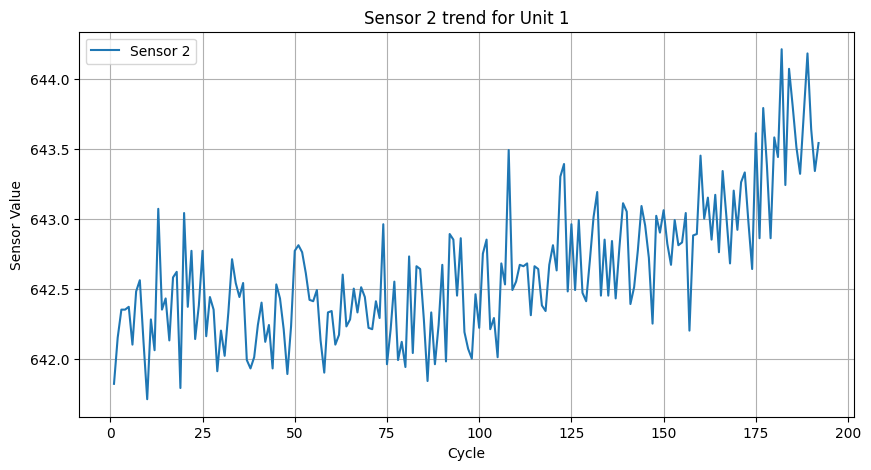

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the data path
# data_path = r'C:\Users\Achintya\Desktop\idl_project\6.+Turbofan+Engine+Degradation+Simulation+Data+Set\6. Turbofan Engine Degradation Simulation Data Set\CMAPSSData'
data_path = r'/content/drive/MyDrive/cmu/idl/final_project/idl_project/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData'

# Column names based on the readme.txt
# 1) unit number
# 2) time, in cycles
# 3) operational setting 1
# 4) operational setting 2
# 5) operational setting 3
# 6-26) sensor measurement 1-21

col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(file_name):
    file_path = os.path.join(data_path, file_name)
    # The data is space separated, and there are trailing spaces in the files
    df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)
    return df

if __name__ == "__main__":
    print("Loading FD001 training data...")
    train_df = load_data('train_FD001.txt')

    print("\nData Shape:", train_df.shape)
    print("\nFirst 5 rows:")
    print(train_df.head())

    print("\nData Info:")
    print(train_df.info())

    # Calculate Remaining Useful Life (RUL) for each row
    # RUL = Max Cycle for that unit - Current Cycle
    print("\nCalculating RUL...")

    # Get the maximum cycle for each unit
    max_cycle = train_df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']

    # Merge back to the original dataframe
    train_df = train_df.merge(max_cycle, on=['unit'], how='left')

    # Calculate RUL
    train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

    # Drop max_cycle as it's no longer needed
    train_df.drop('max_cycle', axis=1, inplace=True)

    print("\nFirst 5 rows with RUL:")
    print(train_df[['unit', 'cycle', 'RUL']].head())

    # Plotting sensor 2 for unit 1
    plt.figure(figsize=(10, 5))
    unit1 = train_df[train_df['unit'] == 1]
    plt.plot(unit1['cycle'], unit1['s2'], label='Sensor 2')
    plt.xlabel('Cycle')
    plt.ylabel('Sensor Value')
    plt.title('Sensor 2 trend for Unit 1')
    plt.legend()
    plt.grid(True)
    plt.savefig('sensor_trend_unit1.png')
    print("\nSaved sensor trend plot to 'sensor_trend_unit1.png'")

    # --- Process Test Data ---
    print("\nLoading FD001 test data and ground truth RUL...")
    test_df = load_data('test_FD001.txt')

    # Load the ground truth RUL for the test set
    rul_truth = pd.read_csv(os.path.join(data_path, 'RUL_FD001.txt'), sep='\s+', header=None, names=['true_rul'])
    rul_truth['unit'] = rul_truth.index + 1 # Engine IDs start at 1

    # Get the last cycle for each unit in the test set
    test_max_cycle = test_df.groupby('unit')['cycle'].max().reset_index()
    test_max_cycle.columns = ['unit', 'max_cycle']

    # Merge the true RUL with the max cycle info
    test_df = test_df.merge(test_max_cycle, on=['unit'], how='left')
    test_df = test_df.merge(rul_truth, on=['unit'], how='left')

    # Calculate RUL for every row in the test set
    # RUL = (True RUL at end) + (Max Cycle - Current Cycle)
    test_df['RUL'] = test_df['true_rul'] + (test_df['max_cycle'] - test_df['cycle'])

    # Clean up temporary columns
    test_df.drop(['max_cycle', 'true_rul'], axis=1, inplace=True)

    print("First 5 rows of Test Data with RUL:")
    print(test_df[['unit', 'cycle', 'RUL']].head())

    # Save both tables to CSV files
    train_df.to_csv('processed_train_data.csv', index=False)
    test_df.to_csv('processed_test_data.csv', index=False)
    print("\nSUCCESS: Both 'processed_train_data.csv' and 'processed_test_data.csv' have been saved!")

<h2>Preprocessing.py</h2>

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os

# Define the data path
# data_path = r'C:\Users\Achintya\Desktop\idl_project\6.+Turbofan+Engine+Degradation+Simulation+Data+Set\6. Turbofan Engine Degradation Simulation Data Set\CMAPSSData'
data_path = r'/content/drive/MyDrive/cmu/idl/final_project/idl_project/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData'

col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(file_name):
    file_path = os.path.join(data_path, file_name)
    df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)
    return df

def calculate_train_rul(df):
    # Get max cycle for each unit
    max_cycle = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    # Merge and calculate RUL
    df = df.merge(max_cycle, on=['unit'], how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop('max_cycle', axis=1, inplace=True)
    return df

def calculate_test_rul(test_df, rul_truth_file):
    # Load ground truth
    rul_truth = pd.read_csv(os.path.join(data_path, rul_truth_file), sep='\s+', header=None, names=['true_rul'])
    rul_truth['unit'] = rul_truth.index + 1
    # Get max cycle for test units
    test_max_cycle = test_df.groupby('unit')['cycle'].max().reset_index()
    test_max_cycle.columns = ['unit', 'max_cycle']
    # Merge and calculate RUL
    test_df = test_df.merge(test_max_cycle, on=['unit'], how='left')
    test_df = test_df.merge(rul_truth, on=['unit'], how='left')
    test_df['RUL'] = test_df['true_rul'] + (test_df['max_cycle'] - test_df['cycle'])
    test_df.drop(['max_cycle', 'true_rul'], axis=1, inplace=True)
    return test_df

if __name__ == "__main__":
    # 1. Load Data
    print("Loading raw data...")
    train_df = load_data('train_FD001.txt')
    test_df = load_data('test_FD001.txt')

    # 2. Calculate RUL
    print("Calculating RUL...")
    train_df = calculate_train_rul(train_df)
    test_df = calculate_test_rul(test_df, 'RUL_FD001.txt')

    # 3. Clip RUL (Piecewise Linear RUL)
    # This caps the RUL at 125, as suggested in the tips.
    CLIP_LIMIT = 125
    print(f"Clipping RUL at {CLIP_LIMIT}...")
    train_df['RUL'] = train_df['RUL'].clip(upper=CLIP_LIMIT)
    test_df['RUL'] = test_df['RUL'].clip(upper=CLIP_LIMIT)

    # 4. Identify and Drop Constant Sensors
    # If Min == Max, the sensor is constant and useless.
    print("Identifying constant sensors...")
    constant_sensors = []
    for col in train_df.columns:
        if col.startswith('s'):
            if train_df[col].min() == train_df[col].max():
                constant_sensors.append(col)

    print(f"Dropping constant sensors: {constant_sensors}")
    train_df.drop(columns=constant_sensors, inplace=True)
    test_df.drop(columns=constant_sensors, inplace=True)

    # 5. Normalization (Scaling to 0-1)
    # We normalize everything except the 'unit' ID and the 'RUL' answer.
    cols_to_normalize = train_df.columns.difference(['unit', 'RUL'])

    print(f"Normalizing columns: {list(cols_to_normalize)}")
    scaler = MinMaxScaler()

    # CRITICAL: We fit the scaler ONLY on the training data
    scaler.fit(train_df[cols_to_normalize])

    # Then we transform both train and test
    train_df[cols_to_normalize] = scaler.transform(train_df[cols_to_normalize])
    test_df[cols_to_normalize] = scaler.transform(test_df[cols_to_normalize])

    # 6. Save the results
    print("\nSaving preprocessed data...")
    train_df.to_csv('train_preprocessed.csv', index=False)
    test_df.to_csv('test_preprocessed.csv', index=False)

    print("\nSUCCESS! Files 'train_preprocessed.csv' and 'test_preprocessed.csv' are ready.")
    print(f"Final column count: {len(train_df.columns)}")


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_684/1526902615.py:14: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)
/tmp/ipykernel_684/1526902615.py:29: SyntaxWarning: invalid escape sequence '\s'
  rul_truth = pd.read_csv(os.path.join(data_path, rul_truth_file), sep='\s+', header=None, names=['true_rul'])


Loading raw data...
Calculating RUL...
Clipping RUL at 125...
Identifying constant sensors...
Dropping constant sensors: ['s1', 's5', 's10', 's16', 's18', 's19']
Normalizing columns: ['cycle', 'os1', 'os2', 'os3', 's11', 's12', 's13', 's14', 's15', 's17', 's2', 's20', 's21', 's3', 's4', 's6', 's7', 's8', 's9']

Saving preprocessed data...

SUCCESS! Files 'train_preprocessed.csv' and 'test_preprocessed.csv' are ready.
Final column count: 21


<H2>model.py</h2>

In [4]:
import torch
import torch.nn as nn
import numpy as np

class LSTMModel(nn.Module):
    """
    The 'Brain' of our project.
    It takes a sequence of sensor data and predicts the Remaining Useful Life.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(LSTMModel, self).__init__()

        # 1. The LSTM Layer: This is where the 'memory' lives.
        # batch_first=True means our data looks like (Batch, Time, Features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)

        # 2. A Dropout layer: This randomly turns off some neurons during training.
        # It's like a coach making players practice with one eye closed so they become
        # more robust and don't rely on just one 'star' sensor.
        self.dropout = nn.Dropout(0.2)

        # 3. The Fully Connected Layer: Turns the LSTM's memory into a single prediction.
        self.fc = nn.Linear(hidden_size*2, output_size)

    def forward(self, x):
        # x is our window of data (e.g., 50 cycles of 19 sensors)

        # Pass through LSTM
        # out contains the 'hidden state' for every step in the sequence
        out, _ = self.lstm(x)

        # We only care about the very LAST step in the sequence
        # (the most recent health state of the engine)
        out = out[:, -1, :]

        # Apply dropout and the final linear layer
        out = self.dropout(out)
        out = self.fc(out)

        return out

    # def forward(self, x):
    #     # out: (batch, seq, hidden_size * 2)
    #     # h_n: (num_layers * 2, batch, hidden_size)
    #     out, (h_n, c_n) = self.lstm(x)

    #     # 1. Get the last hidden state of the forward pass
    #     # h_n shape is (num_layers * 2, batch, hidden_size)
    #     # The last two entries in the first dimension are the final forward and backward states
    #     forward_last = h_n[-2, :, :]
    #     backward_last = h_n[-1, :, :]

    #     # 2. Concatenate them
    #     out = torch.cat((forward_last, backward_last), dim=1)

    #     # Apply dropout and the final linear layer
    #     out = self.dropout(out)
    #     out = self.fc(out)

    #     return out


def create_sequences(data, window_size):
    """
    Helper function to turn flat data into sequences/windows.
    """
    sequences = []
    labels = []

    # We process each engine (unit) separately
    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit]

        # Feature columns (everything except unit and RUL)
        # In our preprocessed data, these are cycles, settings, and sensors.
        features = unit_data.drop(columns=['unit', 'RUL']).values
        target = unit_data['RUL'].values

        # Slide the window across the engine's life
        for i in range(len(unit_data) - window_size + 1):
            window = features[i : i + window_size]
            label = target[i + window_size - 1]

            sequences.append(window)
            labels.append(label)

    return np.array(sequences), np.array(labels)

if __name__ == "__main__":
    print("Model definition script. Use train.py to actually train this model.")


Model definition script. Use train.py to actually train this model.


<h2>train.py</h2>

Using device: cuda
Loading preprocessed training data...

Starting Training (100 epochs)...
Epoch [1/100], Loss: 50.8769
Epoch [2/100], Loss: 37.2602
Epoch [3/100], Loss: 36.0931
Epoch [4/100], Loss: 36.0695
Epoch [5/100], Loss: 35.2132
Epoch [6/100], Loss: 17.4822
Epoch [7/100], Loss: 14.4548
Epoch [8/100], Loss: 13.8763
Epoch [9/100], Loss: 13.5380
Epoch [10/100], Loss: 13.5873
Epoch [11/100], Loss: 13.5441
Epoch [12/100], Loss: 13.5583
Epoch [13/100], Loss: 13.2328
Epoch [14/100], Loss: 12.7617
Epoch [15/100], Loss: 12.8859
Epoch [16/100], Loss: 12.8032
Epoch [17/100], Loss: 13.2753
Epoch [18/100], Loss: 12.9976
Epoch [19/100], Loss: 12.7985
Epoch [20/100], Loss: 12.6513
Epoch [21/100], Loss: 12.3282
Epoch [22/100], Loss: 12.2211
Epoch [23/100], Loss: 12.0982
Epoch [24/100], Loss: 10.7579
Epoch [25/100], Loss: 8.7475
Epoch [26/100], Loss: 7.8253
Epoch [27/100], Loss: 7.2860
Epoch [28/100], Loss: 6.8727
Epoch [29/100], Loss: 7.0182
Epoch [30/100], Loss: 6.6260
Epoch [31/100], Loss: 6

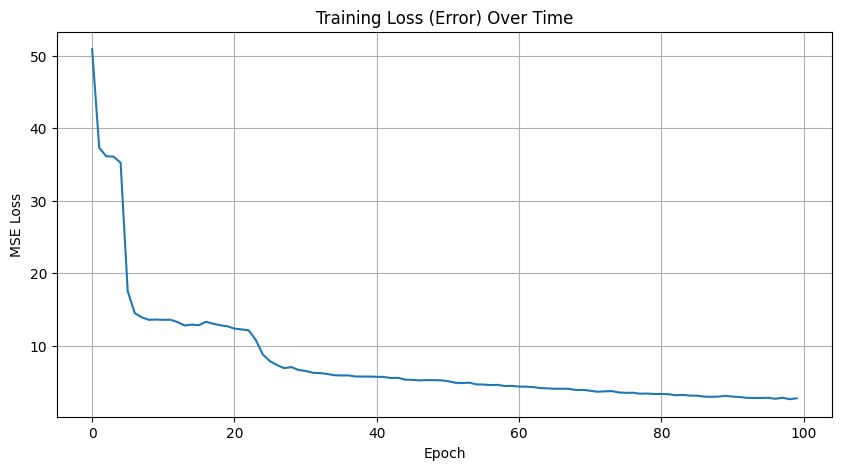

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from model import LSTMModel, create_sequences

# 1. Configuration
WINDOW_SIZE = 50
BATCH_SIZE = 64
HIDDEN_SIZE = 128
NUM_LAYERS = 2
LEARNING_RATE = 0.001
EPOCHS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")

def train_model():
    # 2. Load and Sequence Data
    print("Loading preprocessed training data...")
    train_df = pd.read_csv('train_preprocessed.csv')

    X_train, y_train = create_sequences(train_df, WINDOW_SIZE)

    # Convert to PyTorch Tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    # Create DataLoader (handles shuffling and batches)
    train_data = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

    # 3. Initialize Model, Loss, and Optimizer
    input_size = X_train.shape[2] # Number of features (sensors/settings)
    model = LSTMModel(input_size, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

    criterion = nn.SmoothL1Loss() # Mean Squared Error (best for predicting numbers)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 4. Training Loop
    history = []
    print(f"\nStarting Training ({EPOCHS} epochs)...")

    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)

            # Forward pass (the guess)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            # Backward pass (the correction)
            optimizer.zero_grad() # Reset math from last batch
            loss.backward()       # Calculate how to fix the weights
            optimizer.step()      # Apply the fix

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

    # 5. Save the trained model
    torch.save(model.state_dict(), 'lstm_model.pth')
    print("\nModel saved as 'lstm_model.pth'")

    # 6. Plot the loss history
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title('Training Loss (Error) Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.savefig('training_loss.png')
    print("Loss plot saved as 'training_loss.png'")

if __name__ == "__main__":
    train_model()


<h2>evaluate.py</h2>

Loading preprocessed test data...
Making predictions...

Final Test RMSE: 14.14
Results plot saved as 'evaluation_results.png'


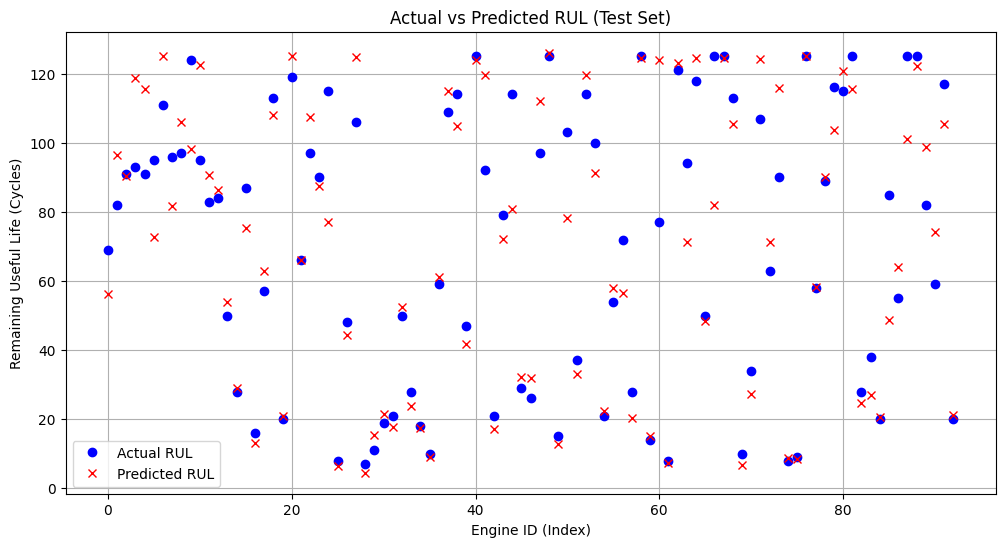

In [6]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
# from model import LSTMModel

# 1. Configuration
WINDOW_SIZE = 50
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_model():
    # 2. Load the test data
    print("Loading preprocessed test data...")
    test_df = pd.read_csv('test_preprocessed.csv')

    # 3. Prepare sequences for the Test Set
    # Important: In the test set, we only care about the VERY LAST window for each engine
    # because that's where we need to make our prediction.
    X_test = []
    y_test = []

    for unit in test_df['unit'].unique():
        unit_data = test_df[test_df['unit'] == unit]

        if len(unit_data) >= WINDOW_SIZE:
            # Grab the last window_size cycles
            features = unit_data.drop(columns=['unit', 'RUL']).values
            window = features[-WINDOW_SIZE:]
            label = unit_data['RUL'].iloc[-1] # The actual RUL at the end

            X_test.append(window)
            y_test.append(label)
        else:
            # If an engine has less than 50 cycles, we can't use our window size.
            # For simplicity, we'll skip these or pad them. In FD001, most are > 50.
            print(f"Warning: Unit {unit} has only {len(unit_data)} cycles. Skipping.")

    X_test = torch.tensor(np.array(X_test), dtype=torch.float32).to(DEVICE)
    y_test = np.array(y_test)

    # 4. Load the trained model
    input_size = X_test.shape[2]
    model = LSTMModel(input_size, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)
    model.load_state_dict(torch.load('lstm_model.pth'))
    model.eval() # Put model in 'evaluation mode'

    # 5. Make Predictions
    print("Making predictions...")
    with torch.no_grad():
        predictions = model(X_test)
        predictions = predictions.cpu().numpy().flatten()

    # 6. Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"\nFinal Test RMSE: {rmse:.2f}")

    # 7. Visualize Results
    plt.figure(figsize=(12, 6))
    plt.plot(y_test, label='Actual RUL', color='blue', marker='o', linestyle='')
    plt.plot(predictions, label='Predicted RUL', color='red', marker='x', linestyle='')
    plt.title('Actual vs Predicted RUL (Test Set)')
    plt.xlabel('Engine ID (Index)')
    plt.ylabel('Remaining Useful Life (Cycles)')
    plt.legend()
    plt.grid(True)
    plt.savefig('evaluation_results.png')
    print("Results plot saved as 'evaluation_results.png'")

if __name__ == "__main__":
    evaluate_model()
